# UI Object Detection
1. Contour Detection
1. YOLOv11

You can download YOLOv11 model in: https://huggingface.co/agzulvani/sketch-ui-deep-net/tree/main
For contour detection please using OpenCV

In [7]:
#!pip install --upgrade pip
#!pip install -U opencv-python
#!pip install -U matplotlib

In [8]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

In [9]:
def binarization(citra, thresold):
    row = citra.shape[0]
    column = citra.shape[1]
    hasil = np.zeros((row, column), np.uint8)
    for i in range(row):
        for j in range(column):
            if citra[i, j] >= thresold:
                hasil[i, j] = 0
            else:
                hasil[i, j] = 255    
    return hasil 

    # Define a kernel for dilation
    # kernel = np.ones((1, 1), np.uint8)  # 5x5 square kernel
    # citra = cv2.dilate(citra, kernel, iterations=1)


In [10]:
def normalization(citra):
    row = citra.shape[0]
    column = citra.shape[1]
    hasil = np.zeros((row, column), np.uint8)

    for i in range(row):
        for j in range(column):
            if citra[i, j] == 255:
                hasil[i, j] = 0
            else:
                hasil[i, j] = 1    
    return hasil 

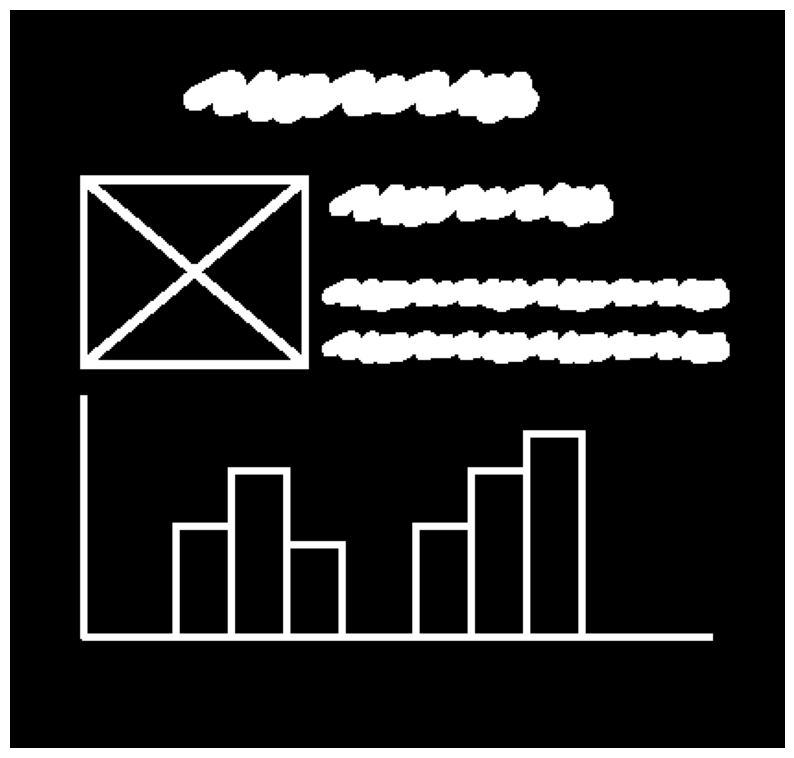

In [13]:
# IMAGE PRE-PROCESSING BEFORE OBJECT DETECTION
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from ultralytics import YOLO

source = '/Users/aguszulvani/Downloads/digital-wireframe-illustration.png'

citra = cv2.imread(source, cv2.IMREAD_GRAYSCALE)

citra = binarization(citra, 200)
kernel = np.ones((3, 3), np.uint8)  
citra = cv2.dilate(citra, kernel, iterations=1)

hasil = citra
plt.figure(figsize=(10,10))
plt.imshow(citra, cmap='gray')
plt.axis('off')
plt.show()


WARNING ⚠️ imgsz=[420] must be multiple of max stride 32, updating to [448]
image 1/1 /Users/aguszulvani/LEARNING-ML/DSL/FINAL_RESULT/CODE/YOLOv11-detection.png: 448x448 (no detections), 97.6ms
Speed: 3.1ms preprocess, 97.6ms inference, 3.6ms postprocess per image at shape (1, 3, 448, 448)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([])
conf: tensor([])
data: tensor([], size=(0, 6))
id: None
is_track: False
orig_shape: (400, 420)
shape: torch.Size([0, 6])
xywh: tensor([], size=(0, 4))
xywhn: tensor([], size=(0, 4))
xyxy: tensor([], size=(0, 4))
xyxyn: tensor([], size=(0, 4))


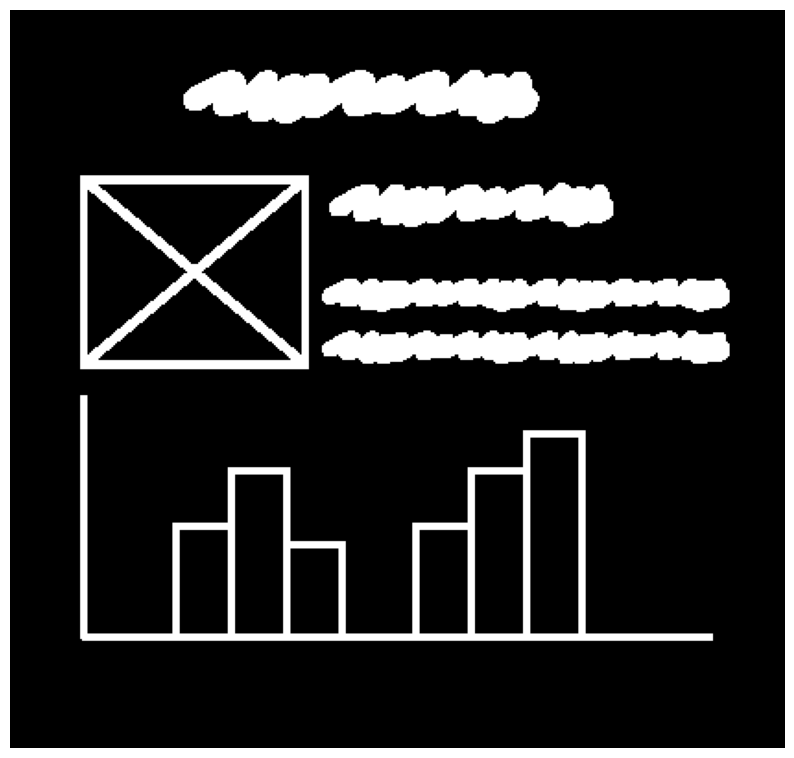

In [11]:
# OBJECT DETECTION WITH YOLOv11
output_path = 'YOLOv11-detection.png'
cv2.imwrite(output_path, citra)

# plt.figure(figsize=(10,10))
# plt.imshow(citra, cmap='gray')
# plt.show()

best_model = YOLO('/Users/aguszulvani/privacy/MKOM/1-PROPOSAL-TESIS/EXPERIENCE-RESULT/YOLO/YOLOv11/weights/best.pt')
results = best_model.predict(output_path, imgsz=citra.shape[1], agnostic_nms=False)
hasil = results[0]
print(hasil.boxes)
img_detect = hasil.plot(line_width=1)

# Get the coordinates of the top-left and bottom-right positions
for box in hasil.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])  # Bounding box coordinates
    cls = int(box.cls[0].item()) 
    class_name = best_model.names[cls]
    print(f"Top-left: ({x1}, {y1}), Bottom-right: ({x2}, {y2})", f"Class: {class_name}")

plt.figure(figsize=(10, 10))
plt.imshow(img_detect)
plt.axis('off')  # Hide axes for better visualization
plt.show()

(38, 209) (381, 342)
(169, 174) (390, 192)
(169, 146) (390, 164)
(173, 94) (327, 118)
(38, 90) (162, 195)
(94, 33) (287, 62)


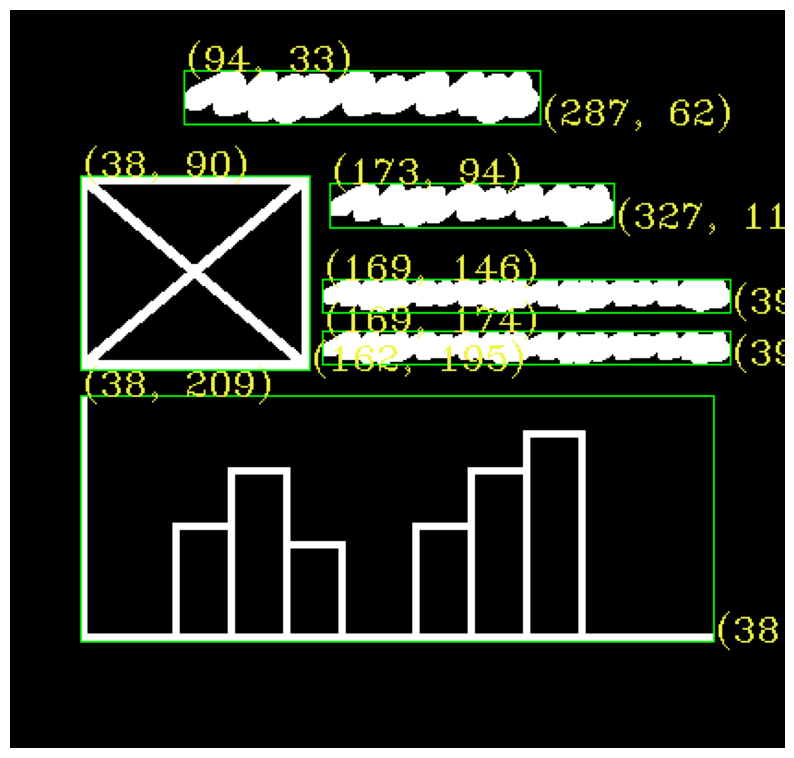

32


In [14]:
# contours, hierarchy = cv2.findContours(hasil, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours, hierarchy = cv2.findContours(hasil, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output_image = cv2.cvtColor(hasil, cv2.COLOR_GRAY2BGR)

# print(contours)
i = 0
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    # print(cv2.boundingRect(contour))
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 1)

    top_left = (x, y)
    bottom_right = (x + w, y + h)

     # Draw the top-left corner coordinates
    cv2.putText(output_image, str(top_left), top_left, cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (239, 245, 66), 1)

    # Draw the bottom-right corner coordinates
    cv2.putText(output_image, str(bottom_right), bottom_right, cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (239, 245, 66), 1)


    print(top_left, bottom_right)
    i = i + 1

# cv2.drawContours(output_image, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(10,10))
plt.imshow(output_image, cmap='gray')
plt.axis('off')
plt.show()

print(len(contours[0]))

#np.savetxt('output.txt', contours[0], fmt='%d')  # Use %d for integers, %f for floats

# i = 0
# for obj in contours:
#     print(i)
#     for point in obj:
#         x = point[0][0] 
#         y = point[0][1] 
#         print(x, y, '=', hasil[y, x]) 
#     i = i + 1
    

In [15]:
# MENGHITUNG IOU
from ultralytics import YOLO
import os
import json

def load_ground_truth(via_json_file):
    with open(via_json_file, 'r') as f:
        data = json.load(f)

    gt_boxes = []
    for img_id, img_data in data["_via_img_metadata"].items():
        for region in img_data["regions"]:
            shape = region["shape_attributes"]
            if shape["name"] == "rect":
                x1 = shape["x"]
                y1 = shape["y"]
                x2 = x1 + shape["width"]
                y2 = y1 + shape["height"]
                gt_boxes.append([x1, y1, x2, y2])
    return gt_boxes

def do_calculate_iou(boxA, boxB):
    # boxA, boxB = [x1, y1, x2, y2]

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # intersection area
    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight

    # area of both boxes
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # IoU
    iou = interArea / float(boxAArea + boxBArea - interArea) if (boxAArea + boxBArea - interArea) > 0 else 0
    return iou

def calculate_iou(fullPathInputImageFile, ground_truth_boxes_file, base_dir_name):
    
    # fullPathInputImageFile = '/Users/aguszulvani/goota/httpd_doc_root/generated-wireframe/test-mobile-6-sign-in-with-alert/test-mobile-6-sign-in-with-alert.jpg'

    resultFileFullPath = os.path.join('/Users/aguszulvani/goota/httpd_doc_root/generated-wireframe', base_dir_name, base_dir_name + '-yolov11-iou.json')
    print(f"Result File: {resultFileFullPath}")

    citra = cv2.imread(fullPathInputImageFile, cv2.IMREAD_GRAYSCALE)
    citra = binarization(citra, 200)

    kernel = np.ones((3, 3), np.uint8)  # 5x5 square kernel
    citra = cv2.dilate(citra, kernel, iterations=1)

    best_model = YOLO('/Users/aguszulvani/privacy/MKOM/1-PROPOSAL-TESIS/EXPERIENCE-RESULT/YOLO/YOLOv11/weights/best.pt')
    results = best_model.predict(fullPathInputImageFile, imgsz=citra.shape[1], agnostic_nms=False)
    hasil = results[0]

    ground_truth_boxes = load_ground_truth(ground_truth_boxes_file)

    result = []
    i = 0
    for box in hasil.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  
        pred_box = [x1,y1, x2, y2]
        result.append(do_calculate_iou(pred_box, ground_truth_boxes[i]))
        i = i + 1
    
    return sum(result) / len(result) if result else 0
   
m_draw_io = []
m_hd_1 = []
m_hd_2 = []
m_hd_3 = []
m_hd_4 = []
m_hd_5 = []

d_draw_io = []
d_hd_1 = []
d_hd_2 = []
d_hd_3 = []
d_hd_4 = []
d_hd_5 = []
    
# Loop through all files in the directory
directory = '/Users/aguszulvani/goota/httpd_doc_root/generated-wireframe'
for folder in os.listdir(directory):
    if os.path.isdir(os.path.join(directory, folder)):
        for filename in os.listdir(os.path.join(directory, folder)):
            if filename.endswith('.jpg') or filename.endswith('.png'):  
                fullPathInputImageFile = os.path.join(directory, filename)
                filename_without_extension = os.path.splitext(filename)[0]
                if folder == filename_without_extension:
                    fullPathInputImageFile = os.path.join(directory, folder, filename)
                    cocoFile = os.path.join(directory, folder, filename_without_extension + '-ground-truth.json')
                    iou = calculate_iou(fullPathInputImageFile, ground_truth_boxes_file=cocoFile, base_dir_name=folder)
                    
                    if "mobile" in folder:
                        if "hand" not in folder:
                            m_draw_io.append(iou)

                        if "agus" in folder:
                            m_hd_1.append(iou)
                        
                        if "tia" in folder:
                            m_hd_2.append(iou)

                        if "dimas" in folder:
                            m_hd_3.append(iou)

                        if "pazrin" in folder:
                            m_hd_4.append(iou)

                        if "fadli" in folder:
                            m_hd_5.append(iou)

                    if "desktop" in folder:
                        if "hand" not in folder:
                            d_draw_io.append(iou)

                        if "agus" in folder:
                            d_hd_1.append(iou)
                        
                        if "tia" in folder:
                            d_hd_2.append(iou)

                        if "dimas" in folder:
                            d_hd_3.append(iou)

                        if "pazrin" in folder:
                            d_hd_4.append(iou)

                        if "fadli" in folder:
                            d_hd_5.append(iou)


 # Calculate and print the averages for all m_ and d_ lists
m_draw_io_avg = sum(m_draw_io) / len(m_draw_io) if m_draw_io else 0
m_hd_1_avg = sum(m_hd_1) / len(m_hd_1) if m_hd_1 else 0
m_hd_2_avg = sum(m_hd_2) / len(m_hd_2) if m_hd_2 else 0
m_hd_3_avg = sum(m_hd_3) / len(m_hd_3) if m_hd_3 else 0
m_hd_4_avg = sum(m_hd_4) / len(m_hd_4) if m_hd_4 else 0
m_hd_5_avg = sum(m_hd_5) / len(m_hd_5) if m_hd_5 else 0

d_draw_io_avg = sum(d_draw_io) / len(d_draw_io) if d_draw_io else 0
d_hd_1_avg = sum(d_hd_1) / len(d_hd_1) if d_hd_1 else 0
d_hd_2_avg = sum(d_hd_2) / len(d_hd_2) if d_hd_2 else 0
d_hd_3_avg = sum(d_hd_3) / len(d_hd_3) if d_hd_3 else 0
d_hd_4_avg = sum(d_hd_4) / len(d_hd_4) if d_hd_4 else 0
d_hd_5_avg = sum(d_hd_5) / len(d_hd_5) if d_hd_5 else 0

# Display averages rounded to 2 decimal places
print(f"m_draw_io_avg: {round(m_draw_io_avg, 2)}")
print(f"m_hd_1_avg: {round(m_hd_1_avg, 2)}")
print(f"m_hd_2_avg: {round(m_hd_2_avg, 2)}")
print(f"m_hd_3_avg: {round(m_hd_3_avg, 2)}")
print(f"m_hd_4_avg: {round(m_hd_4_avg, 2)}")
print(f"m_hd_5_avg: {round(m_hd_5_avg, 2)}")

print(f"d_draw_io_avg: {round(d_draw_io_avg, 2)}")
print(f"d_hd_1_avg: {round(d_hd_1_avg, 2)}")
print(f"d_hd_2_avg: {round(d_hd_2_avg, 2)}")
print(f"d_hd_3_avg: {round(d_hd_3_avg, 2)}")
print(f"d_hd_4_avg: {round(d_hd_4_avg, 2)}")
print(f"d_hd_5_avg: {round(d_hd_5_avg, 2)}")

Result File: /Users/aguszulvani/goota/httpd_doc_root/generated-wireframe/test-desktop-6-hand-dimas-hosting-personal-information/test-desktop-6-hand-dimas-hosting-personal-information-yolov11-iou.json

WARNING ⚠️ imgsz=[1032] must be multiple of max stride 32, updating to [1056]
image 1/1 /Users/aguszulvani/goota/httpd_doc_root/generated-wireframe/test-desktop-6-hand-dimas-hosting-personal-information/test-desktop-6-hand-dimas-hosting-personal-information.jpg: 1056x640 1 common-button, 1 input-number, 2 time-pickers, 341.7ms
Speed: 4.0ms preprocess, 341.7ms inference, 4.8ms postprocess per image at shape (1, 3, 1056, 640)
Result File: /Users/aguszulvani/goota/httpd_doc_root/generated-wireframe/test-mobile-11-hand-pazrin-simple-browse/test-mobile-11-hand-pazrin-simple-browse-yolov11-iou.json

WARNING ⚠️ imgsz=[396] must be multiple of max stride 32, updating to [416]
image 1/1 /Users/aguszulvani/goota/httpd_doc_root/generated-wireframe/test-mobile-11-hand-pazrin-simple-browse/test-mobile